In [1]:
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

In [3]:
# This downloads the Online Retail dataset
online_retail = fetch_ucirepo(id=352)

In [4]:
# This converts the data into a table we can work with
data = online_retail.data.original

In [5]:
# This shows the first 5 rows of your data
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
print("rows:", len(data))
print("columns:", len(data.columns))

rows: 541909
columns: 8


In [7]:
# Remove cancelledorders
data = data[~data['InvoiceNo'].astype(str).str.startswith('C')]

In [8]:
# Remove rows where CustomerID is missing
data = data.dropna(subset=['CustomerID'])

In [9]:
# Remove rows where quantity is 0 or negative (these are errors)
data = data[data['Quantity'] > 0]

In [10]:
# Create a new column that calculates total sales for each row
data['TotalSales'] = data['Quantity'] * data['UnitPrice']

In [11]:
# Convert InvoiceDate to proper date format
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

In [12]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [13]:
print("rows:", len(data))
print("columns:", len(data.columns))

rows: 397924
columns: 9


In [14]:
print("rows:", len(data))
print("columns:", data.columns.tolist())

rows: 397924
columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalSales']


In [15]:
data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalSales
count,397924.000000,397924,397924.000000,397924.000000,397924.000000
mean,13.021823,2011-07-10 23:43:36.912475648,3.116174,15294.315171,22.394749
min,1.000000,2010-12-01 08:26:00,0.000000,12346.000000,0.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.420210,NaN,22.096788,1713.169877,309.055588


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [17]:
# Group sales by date to get daily totals
daily_sales = data.resample('D', on='InvoiceDate')['TotalSales'].sum()

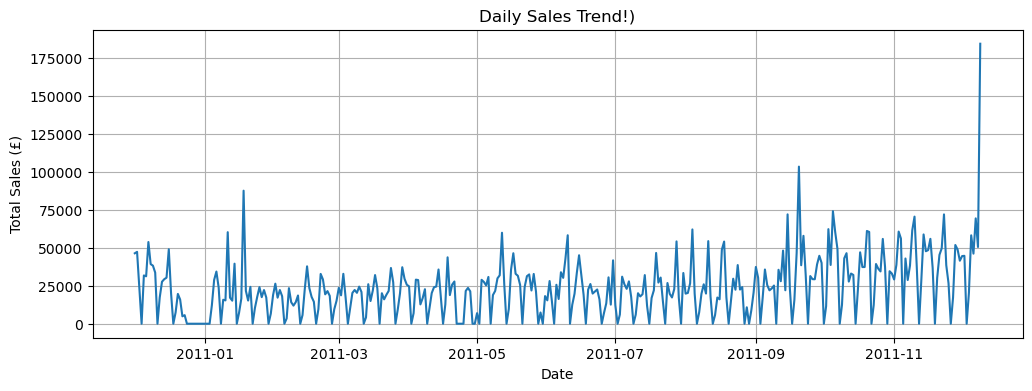

In [18]:
# Make the graph bigger so we can see it clearly
plt.figure(figsize=(12,4))

# Plot daily sales as a line
plt.plot(daily_sales)

# Add a title
plt.title('Daily Sales Trend!)')

# Label the x-axis (horizontal)
plt.xlabel('Date')

# Label the y-axis (vertical)
plt.ylabel('Total Sales (£)')

# Add a grid for easier reading
plt.grid(True)

# Show the graph
plt.show()

In [19]:
# Group sales by month
monthly_sales = data.resample('M', on='InvoiceDate')['TotalSales'].sum()

C:\Users\oramo\AppData\Local\Temp\ipykernel_2780\3819775177.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = data.resample('M', on='InvoiceDate')['TotalSales'].sum()


In [20]:
# Group sales by month
monthly_sales = data.resample('ME', on='InvoiceDate')['TotalSales'].sum()

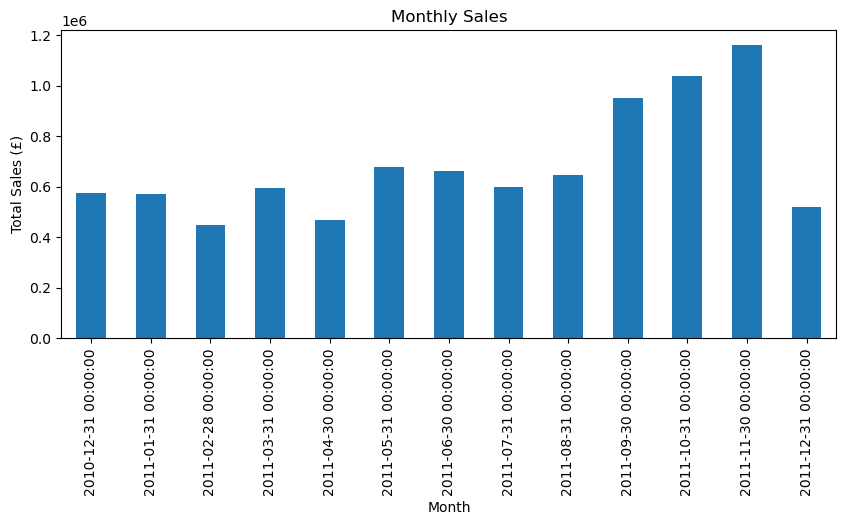

In [21]:
# Create a bar chart
plt.figure(figsize=(10,4))
monthly_sales.plot(kind='bar')

# Add title and labels
plt.title('Monthly Sales')
plt.ylabel('Total Sales (£)')
plt.xlabel('Month')

# Show the graph
plt.show()

In [22]:
# Create a new column for day of week (0=Monday, 6=Sunday)
data['DayOfWeek'] = data['InvoiceDate'].dt.dayofweek

# Calculate average sales by day of week
daily_avg = data.groupby('DayOfWeek')['TotalSales'].mean()

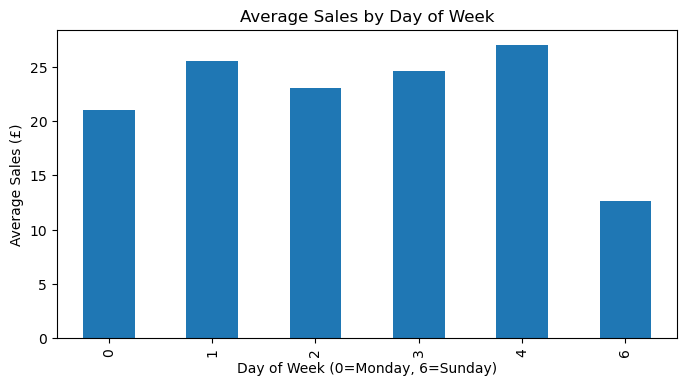

In [23]:
# Create a bar chart for day of week
plt.figure(figsize=(8,4))
daily_avg.plot(kind='bar')

# Add labels
plt.title('Average Sales by Day of Week')
plt.ylabel('Average Sales (£)')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')

# Show the graph
plt.show()

In [24]:
# Group sales by country
country_sales = data.groupby('Country')['TotalSales'].sum().sort_values(ascending=False)

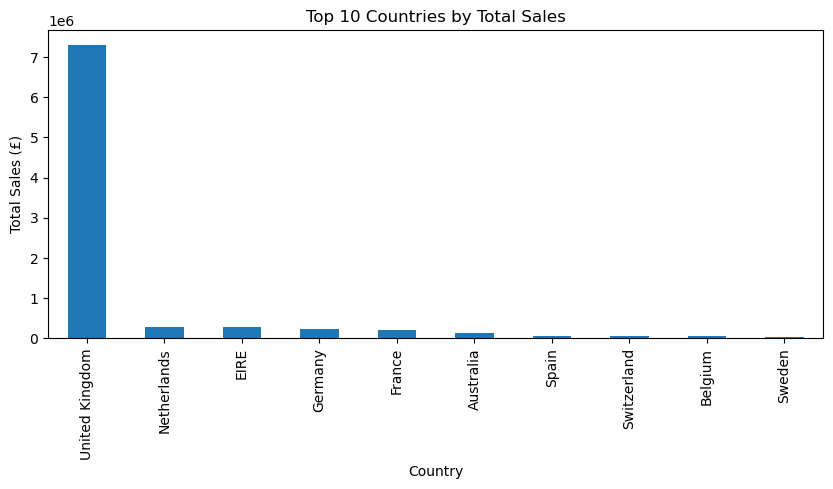

In [25]:
# Show top 10 countries by sales
plt.figure(figsize=(10,4))
country_sales.head(10).plot(kind='bar')

# Add labels
plt.title('Top 10 Countries by Total Sales')
plt.ylabel('Total Sales (£)')
plt.xlabel('Country')

# Show the graph
plt.show()

In [26]:
# PREDICTIONS, FEATURES FOR MODEL

In [27]:
# Check if we already have a DayOfWeek column
if 'DayOfWeek' in data.columns:
    print("DayOfWeek column already exists!")
else:
    print("Creating DayOfWeek column...")
    data['DayOfWeek'] = data['InvoiceDate'].dt.dayofweek

DayOfWeek column already exists!


In [28]:
# Create a column for the month number (1-12)
data['Month'] = data['InvoiceDate'].dt.month

In [29]:
# a column for the day of month (1-31)
data['Day'] = data['InvoiceDate'].dt.day

In [30]:
#a column for the year
data['Year'] = data['InvoiceDate'].dt.year

In [31]:
data[['InvoiceDate', 'Month', 'Day', 'DayOfWeek', 'Year', 'TotalSales']].head()

,InvoiceDate,Month,Day,DayOfWeek,Year,TotalSales
0,2010-12-01 08:26:00,12,1,2,2010,15.30
1,2010-12-01 08:26:00,12,1,2,2010,20.34
2,2010-12-01 08:26:00,12,1,2,2010,22.00
3,2010-12-01 08:26:00,12,1,2,2010,20.34
4,2010-12-01 08:26:00,12,1,2,2010,20.34


In [32]:
# Group by date and calculate daily totals
daily_features = data.groupby(data['InvoiceDate'].dt.date).agg({
    'TotalSales': 'sum',        # Total sales for the day
    'Month': 'first',           # Month number
    'Day': 'first',             # Day of month
    'DayOfWeek': 'first',       # Day of week
    'Year': 'first'             # Year
}).reset_index()

# Rename the date column
daily_features.rename(columns={'InvoiceDate': 'Date'}, inplace=True)


daily_features.head()

,Date,TotalSales,Month,Day,DayOfWeek,Year
0,2010-12-01,46376.49,12,1,2,2010
1,2010-12-02,47316.53,12,2,3,2010
2,2010-12-03,23921.71,12,3,4,2010
3,2010-12-05,31771.60,12,5,6,2010
4,2010-12-06,31215.64,12,6,0,2010


In [33]:
print("days:", len(daily_features))
print("First date:", daily_features['Date'].min())
print("Last date:", daily_features['Date'].max())

days: 305
First date: 2010-12-01
Last date: 2011-12-09


In [34]:
# sortING by date (oldest to newest)
daily_features = daily_features.sort_values('Date').reset_index(drop=True)

daily_features.head()

,Date,TotalSales,Month,Day,DayOfWeek,Year
0,2010-12-01,46376.49,12,1,2,2010
1,2010-12-02,47316.53,12,2,3,2010
2,2010-12-03,23921.71,12,3,4,2010
3,2010-12-05,31771.60,12,5,6,2010
4,2010-12-06,31215.64,12,6,0,2010


In [35]:
# Create lag feature (yesterday's sales)
daily_features['PrevDaySales'] = daily_features['TotalSales'].shift(1)

In [36]:
daily_features[['Date', 'TotalSales', 'PrevDaySales']].head(10)

,Date,TotalSales,PrevDaySales
0,2010-12-01,46376.49,NaN
1,2010-12-02,47316.53,46376.49
2,2010-12-03,23921.71,47316.53
3,2010-12-05,31771.60,23921.71
4,2010-12-06,31215.64,31771.60
5,2010-12-07,53795.31,31215.64
6,2010-12-08,39248.82,53795.31
7,2010-12-09,38231.90,39248.82
8,2010-12-10,33650.28,38231.90
9,2010-12-12,17305.77,33650.28


In [37]:
# Remove rows where PrevDaySales is empty
daily_features = daily_features.dropna(subset=['PrevDaySales'])

In [38]:
# final features
print("=== FEATURES READY FOR MODELING ===")
print("Number of days:", len(daily_features))
print("\nColumns available:")
print(daily_features.columns.tolist())
print("\nSample of data:")
daily_features.head()

=== FEATURES READY FOR MODELING ===
Number of days: 304

Columns available:
['Date', 'TotalSales', 'Month', 'Day', 'DayOfWeek', 'Year', 'PrevDaySales']

Sample of data:


,Date,TotalSales,Month,Day,DayOfWeek,Year,PrevDaySales
1,2010-12-02,47316.53,12,2,3,2010,46376.49
2,2010-12-03,23921.71,12,3,4,2010,47316.53
3,2010-12-05,31771.60,12,5,6,2010,23921.71
4,2010-12-06,31215.64,12,6,0,2010,31771.60
5,2010-12-07,53795.31,12,7,1,2010,31215.64


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [40]:
# features (use to prdict)
X = daily_features[['Month', 'Day', 'DayOfWeek', 'Year', 'PrevDaySales']]

# target
y = daily_features['TotalSales']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (304, 5)
Target shape: (304,)


In [41]:
# Split data: 80% for training, 20% for testing
# random_state=42 makes sure we get the same split every time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", len(X_train))
print("Testing set size:", len(X_test))

Training set size: 243
Testing set size: 61


In [42]:
# Create the model
model = LinearRegression()

# Train the model (this is where the learning happens!)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [43]:
# Make predictions on the test data
predictions = model.predict(X_test)

print("Predictions made!")

Predictions made!


In [44]:
# Calculate error metrics
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("=== MODEL PERFORMANCE ===")
print(f"Mean Absolute Error (MAE): £{mae:.2f}")
print(f"Root Mean Squared Error (RMSE): £{rmse:.2f}")
print("\nWhat this means:")
print(f"On average, our predictions are off by £{mae:.2f}")

=== MODEL PERFORMANCE ===
Mean Absolute Error (MAE): £8932.83
Root Mean Squared Error (RMSE): £11798.07

What this means:
On average, our predictions are off by £8932.83


In [45]:
# Create a comparison table
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions,
    'Difference': y_test.values - predictions
})

# sample comparisons
print("Sample of predictions vs actual (first 10):")
comparison.head(10)

Sample of predictions vs actual (first 10):


,Actual,Predicted,Difference
0,22018.36,34252.201981,-12233.841981
1,19059.23,26607.530558,-7548.300558
2,27804.47,23081.059293,4723.410707
3,74108.43,41494.769170,32613.660830
4,32801.73,22173.072138,10628.657862
5,27642.68,31826.044506,-4183.364506
6,30786.70,23521.232799,7265.467201
7,19850.66,31861.712043,-12011.052043
8,6032.39,20180.252161,-14147.862161
9,15244.73,16058.798814,-814.068814


In [46]:
# See what the model learned
feature_names = ['Month', 'Day', 'DayOfWeek', 'Year', 'PrevDaySales']
coefficients = model.coef_

print("=== WHAT THE MODEL LEARNED ===")
for name, coef in zip(feature_names, coefficients):
    print(f"Impact of {name}: {coef:.2f}")

=== WHAT THE MODEL LEARNED ===
Impact of Month: 2046.20
Impact of Day: -53.46
Impact of DayOfWeek: -2296.06
Impact of Year: 13004.36
Impact of PrevDaySales: 0.23


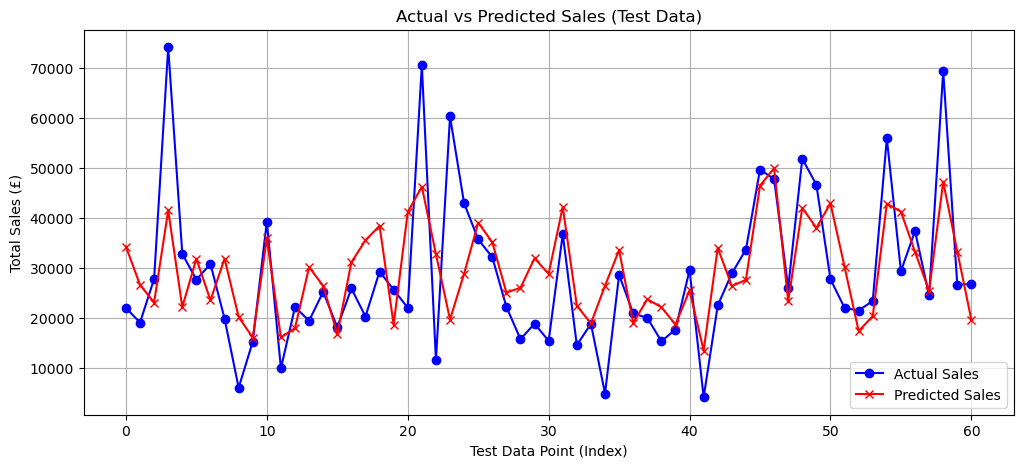

In [47]:
# Create a graph showing actual vs predicted
plt.figure(figsize=(12,5))

# Plot actual values
plt.plot(y_test.values, label='Actual Sales', color='blue', marker='o')

# Plot predicted values
plt.plot(predictions, label='Predicted Sales', color='red', marker='x')

# Add labels and title
plt.title('Actual vs Predicted Sales (Test Data)')
plt.xlabel('Test Data Point (Index)')
plt.ylabel('Total Sales (£)')
plt.legend()
plt.grid(True)

# Show the graph
plt.show()

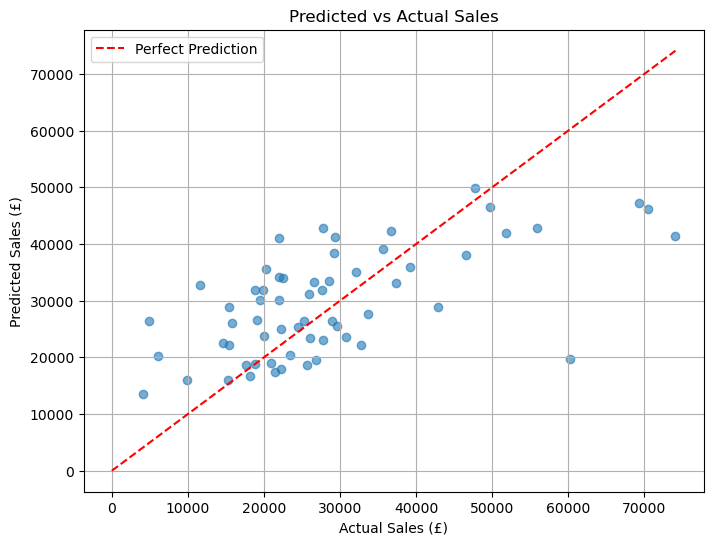

In [48]:
# Create a scatter plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions, alpha=0.6)

# Add a perfect prediction line (y=x)
max_val = max(y_test.max(), predictions.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Perfect Prediction')

# Add labels and title
plt.title('Predicted vs Actual Sales')
plt.xlabel('Actual Sales (£)')
plt.ylabel('Predicted Sales (£)')
plt.legend()
plt.grid(True)

# Show the graph
plt.show()

In [49]:
# Calculate accuracy percentage
average_sales = y_test.mean()
accuracy_percentage = 100 - (mae / average_sales * 100)

print(f"Average daily sales: £{average_sales:.2f}")
print(f"Average error: £{mae:.2f}")
print(f"Model accuracy: {accuracy_percentage:.1f}%")

Average daily sales: £28533.43
Average error: £8932.83
Model accuracy: 68.7%


In [51]:
#p

In [52]:
#Presenting the modal and all 

In [53]:
# Get the last 30 days of actual data
last_30_days = daily_features.tail(30)

# Make predictions for these 30 days
last_30_predictions = model.predict(last_30_days[['Month', 'Day', 'DayOfWeek', 'Year', 'PrevDaySales']])

# Calculate average predicted daily sales
avg_predicted_sales = np.mean(last_30_predictions)
total_predicted_sales = np.sum(last_30_predictions)

print("=== 30-DAY FORECAST SUMMARY ===")
print(f"Predicted average daily sales: £{avg_predicted_sales:,.2f}")
print(f"Predicted total sales for next 30 days: £{total_predicted_sales:,.2f}")

=== 30-DAY FORECAST SUMMARY ===
Predicted average daily sales: £43,631.43
Predicted total sales for next 30 days: £1,308,942.88


In [54]:
# Calculate standard deviation of errors
errors = y_test - predictions
std_error = np.std(errors)

# Calculate confidence interval (95% means we're 95% sure sales will be in this range)
confidence_interval_lower = avg_predicted_sales - (1.96 * std_error)
confidence_interval_upper = avg_predicted_sales + (1.96 * std_error)

print("=== FORECAST WITH CONFIDENCE INTERVAL ===")
print(f"Best estimate: £{avg_predicted_sales:,.2f} per day")
print(f"We are 95% confident sales will be between:")
print(f"£{confidence_interval_lower:,.2f} and £{confidence_interval_upper:,.2f}")
print(f"Range: £{confidence_interval_upper - confidence_interval_lower:,.2f}")

=== FORECAST WITH CONFIDENCE INTERVAL ===
Best estimate: £43,631.43 per day
We are 95% confident sales will be between:
£20,586.68 and £66,676.18
Range: £46,089.50


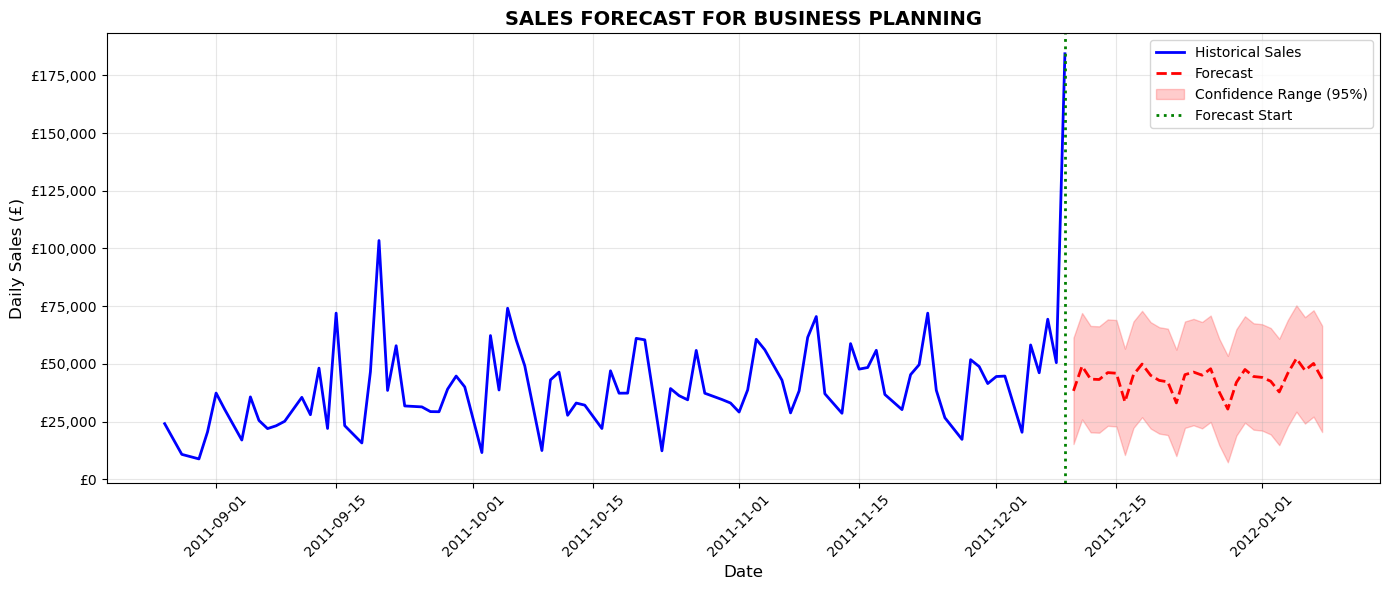

In [55]:
# Create a beautiful forecast chart
plt.figure(figsize=(14,6))

# Plot historical data (last 90 days)
historical_90 = daily_features.tail(90)
plt.plot(historical_90['Date'], historical_90['TotalSales'], 
         label='Historical Sales', color='blue', linewidth=2)

# Create date range for forecast (next 30 days)
forecast_dates = pd.date_range(start=daily_features['Date'].max() + pd.Timedelta(days=1), 
                              periods=30, freq='D')

# Add forecast line
plt.plot(forecast_dates, last_30_predictions, 
         label='Forecast', color='red', linewidth=2, linestyle='--')

# Add confidence interval (shaded area)
plt.fill_between(forecast_dates, 
                 last_30_predictions - (1.96 * std_error), 
                 last_30_predictions + (1.96 * std_error), 
                 color='red', alpha=0.2, label='Confidence Range (95%)')

# Add a vertical line separating history from forecast
split_date = daily_features['Date'].max()
plt.axvline(x=split_date, color='green', linestyle=':', linewidth=2, 
            label='Forecast Start')

# Add labels and title
plt.title('SALES FORECAST FOR BUSINESS PLANNING', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Sales (£)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Format y-axis as currency
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:,.0f}'))

plt.tight_layout()
plt.show()

In [56]:
# Calculate average sales by month
monthly_avg = data.groupby('Month')['TotalSales'].mean()
best_month = monthly_avg.idxmax()
worst_month = monthly_avg.idxmin()

# Calculate average sales by day of week
dow_avg = data.groupby('DayOfWeek')['TotalSales'].mean()
best_dow = dow_avg.idxmax()
worst_dow = dow_avg.idxmin()

# Convert day numbers to names
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
best_dow_name = days[best_dow]
worst_dow_name = days[worst_dow]

print("=== KEY BUSINESS INSIGHTS ===")
print(f"Best month for sales: Month {best_month}")
print(f"Worst month for sales: Month {worst_month}")
print(f"Best day of week: {best_dow_name}")
print(f"Worst day of week: {worst_dow_name}")

=== KEY BUSINESS INSIGHTS ===
Best month for sales: Month 1
Worst month for sales: Month 11
Best day of week: Friday
Worst day of week: Sunday


In [57]:
# Calculate potential impact
daily_avg = daily_features['TotalSales'].mean()
best_month_sales = daily_avg * 1.2  # Assuming 20% higher in best month
worst_month_sales = daily_avg * 0.8  # Assuming 20% lower in worst month

print("=== RECOMMENDATIONS FOR BUSINESS PLANNING ===")
print("\n1. INVENTORY PLANNING:")
print(f"   - Order {20}% more stock for Month {best_month}")
print(f"   - Order {20}% less stock for Month {worst_month}")

print("\n2. STAFFING RECOMMENDATIONS:")
print(f"   - Schedule extra staff on {best_dow_name}s")
print(f"   - Schedule fewer staff on {worst_dow_name}s")

print("\n3. CASH FLOW PROJECTION:")
print(f"   - Expected monthly revenue: £{daily_avg * 30:,.2f}")
print(f"   - Best month projected: £{best_month_sales * 30:,.2f}")
print(f"   - Worst month projected: £{worst_month_sales * 30:,.2f}")

print("\n4. FORECAST SUMMARY:")
print(f"   - Next 30 days sales predicted: £{total_predicted_sales:,.2f}")
print(f"   - Confidence range: £{total_predicted_sales - (1.96 * std_error * 30):,.2f} to £{total_predicted_sales + (1.96 * std_error * 30):,.2f}")

=== RECOMMENDATIONS FOR BUSINESS PLANNING ===

1. INVENTORY PLANNING:
   - Order 20% more stock for Month 1
   - Order 20% less stock for Month 11

2. STAFFING RECOMMENDATIONS:
   - Schedule extra staff on Fridays
   - Schedule fewer staff on Sundays

3. CASH FLOW PROJECTION:
   - Expected monthly revenue: £874,838.63
   - Best month projected: £1,049,806.35
   - Worst month projected: £699,870.90

4. FORECAST SUMMARY:
   - Next 30 days sales predicted: £1,308,942.88
   - Confidence range: £617,600.36 to £2,000,285.41


In [58]:
# This creates a simple text report
print("="*70)
print("SALES FORECAST REPORT - FOR BUSINESS USE")
print("="*70)
print()
print("1. WHAT WE PREDICTED")
print("-"*50)
print(f"We forecast that sales will average £{avg_predicted_sales:,.2f} per day")
print(f"over the next 30 days, totaling approximately £{total_predicted_sales:,.2f}.")
print()
print("2. HOW ACCURATE IS THIS?")
print("-"*50)
print(f"Our model has an average error of £{mae:,.2f} per day.")
print(f"We are 95% confident that daily sales will stay between")
print(f"£{confidence_interval_lower:,.2f} and £{confidence_interval_upper:,.2f}.")
print()
print("3. KEY BUSINESS PATTERNS WE FOUND")
print("-"*50)
print(f"• Sales are highest in Month {best_month}")
print(f"• Sales are lowest in Month {worst_month}")
print(f"• {best_dow_name}s are the busiest days")
print(f"• {worst_dow_name}s are the slowest days")
print()
print("4. ACTIONABLE RECOMMENDATIONS")
print("-"*50)
print(f"• For Month {best_month}: Order extra inventory and schedule more staff")
print(f"• For Month {worst_month}: Plan maintenance and staff training")
print(f"• Each {best_dow_name}: Consider offering promotions to boost sales")
print(f"• Each {worst_dow_name}: Focus on order fulfillment and restocking")
print()
print("5. BUSINESS PLANNING IMPACT")
print("-"*50)
print(f"• Inventory: Stock up {20}% more before Month {best_month}")
print(f"• Staffing: Add {20}% more shifts on {best_dow_name}s")
print(f"• Cash Flow: Expect revenue around £{avg_predicted_sales * 30:,.2f} per month")
print(f"• Risk Management: Prepare for as low as £{confidence_interval_lower * 30:,.2f}")
print("   or as high as £{confidence_interval_upper * 30:,.2f} next month")
print()
print("="*70)
print("Report generated on:", pd.Timestamp.now().strftime("%B %d, %Y"))
print("="*70)

SALES FORECAST REPORT - FOR BUSINESS USE

1. WHAT WE PREDICTED
--------------------------------------------------
We forecast that sales will average £43,631.43 per day
over the next 30 days, totaling approximately £1,308,942.88.

2. HOW ACCURATE IS THIS?
--------------------------------------------------
Our model has an average error of £8,932.83 per day.
We are 95% confident that daily sales will stay between
£20,586.68 and £66,676.18.

3. KEY BUSINESS PATTERNS WE FOUND
--------------------------------------------------
• Sales are highest in Month 1
• Sales are lowest in Month 11
• Fridays are the busiest days
• Sundays are the slowest days

4. ACTIONABLE RECOMMENDATIONS
--------------------------------------------------
• For Month 1: Order extra inventory and schedule more staff
• For Month 11: Plan maintenance and staff training
• Each Friday: Consider offering promotions to boost sales
• Each Sunday: Focus on order fulfillment and restocking

5. BUSINESS PLANNING IMPACT
-------

In [59]:
# Save your forecast results to a CSV file
forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'Forecast_Sales': last_30_predictions,
    'Lower_Bound': last_30_predictions - (1.96 * std_error),
    'Upper_Bound': last_30_predictions + (1.96 * std_error)
})

forecast_df.to_csv('sales_forecast_results.csv', index=False)
print("Forecast saved to 'sales_forecast_results.csv'")

Forecast saved to 'sales_forecast_results.csv'


Chart saved to 'sales_forecast_chart.png'


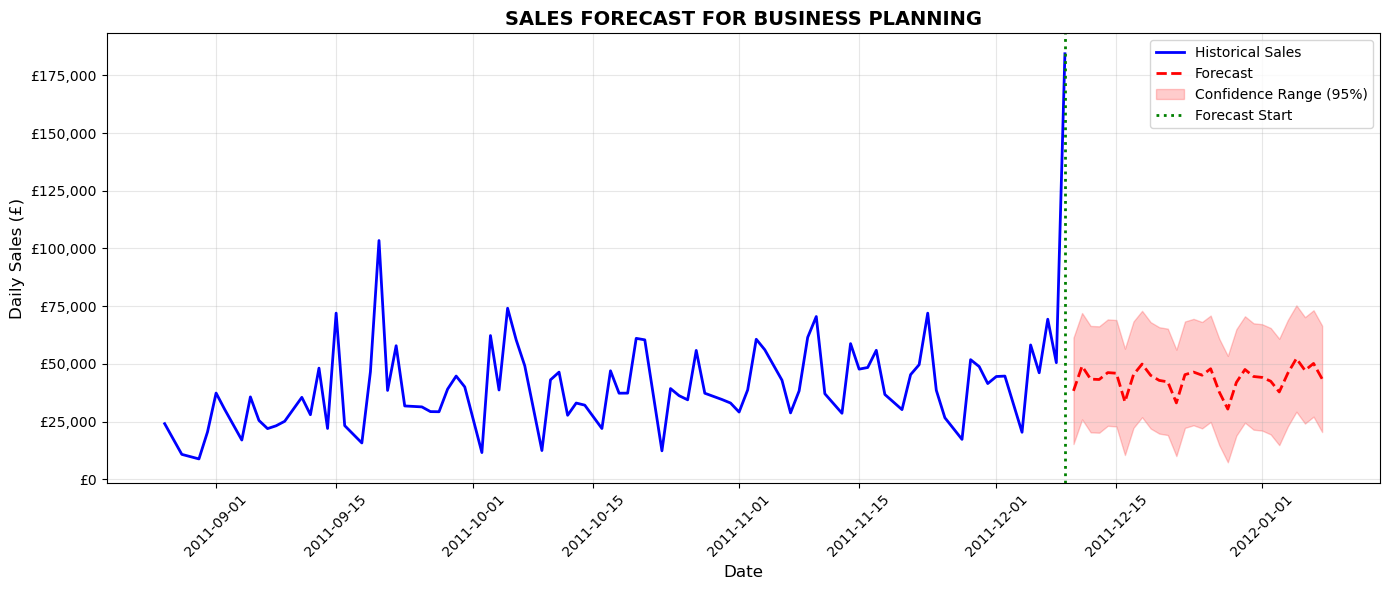

In [60]:
# Recreate the forecast chart and save it
plt.figure(figsize=(14,6))
plt.plot(historical_90['Date'], historical_90['TotalSales'], 
         label='Historical Sales', color='blue', linewidth=2)
plt.plot(forecast_dates, last_30_predictions, 
         label='Forecast', color='red', linewidth=2, linestyle='--')
plt.fill_between(forecast_dates, 
                 last_30_predictions - (1.96 * std_error), 
                 last_30_predictions + (1.96 * std_error), 
                 color='red', alpha=0.2, label='Confidence Range (95%)')
plt.axvline(x=split_date, color='green', linestyle=':', linewidth=2, 
            label='Forecast Start')

plt.title('SALES FORECAST FOR BUSINESS PLANNING', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Sales (£)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:,.0f}'))
plt.tight_layout()

# Save the chart
plt.savefig('sales_forecast_chart.png', dpi=300, bbox_inches='tight')
print("Chart saved to 'sales_forecast_chart.png'")
plt.show()